# `1.noisy_bell` — Bell state with depolarizing noise

This notebook is the MLIR-stack counterpart of
[examples/1.noisy_bell.ipynb](../../examples/1.noisy_bell.ipynb).

We reuse the Bell program from [`0.bell`](0.bell.ipynb) and replay it
under a `DepolarizingNoise` channel attached to the emulator. The same
`Machine` API gains a single new keyword argument — `noise=…` — and
every gate (including the post-measurement reset) gets a Kraus
expansion applied.

In [1]:
%load_ext qstack_mlir.jupyter

## 1. The same Bell program

In [2]:
%%qasm bell
QSTACKQASM 0.1;
include "qstack/cliffords.inc";

qreg q[2];
creg c[2];
h q[0];
cx q[0], q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];

<ModuleOp 4356999792(operands=[], results=[], successors=[], properties={}, attributes={}, regions=[<Region 4356911520>], parent=None, _next_op=None, _prev_op=None)>

## 2. Noiseless baseline

With no noise channel the distribution sits cleanly on `(0, 0)` and
`(1, 1)`.

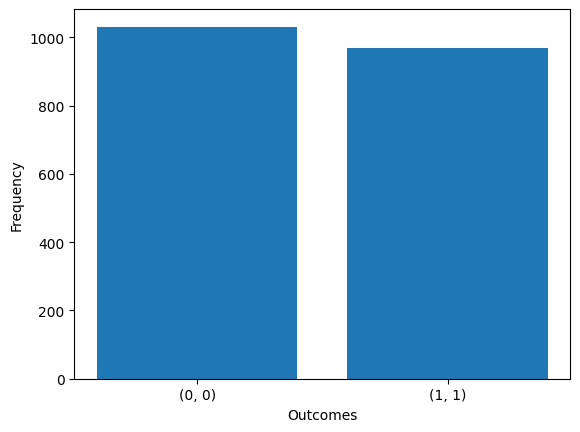

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [3]:
from qstack_mlir.runtime import CallbackRegistry, DepolarizingNoise, Machine

ideal = Machine(bell, num_qubits=4, registry=CallbackRegistry())
ideal.shots("main", 2000).plot_histogram()

## 3. Add depolarizing noise

A small per-gate depolarizing rate already smears measurable weight into
the off-diagonal outcomes `(0, 1)` and `(1, 0)`.

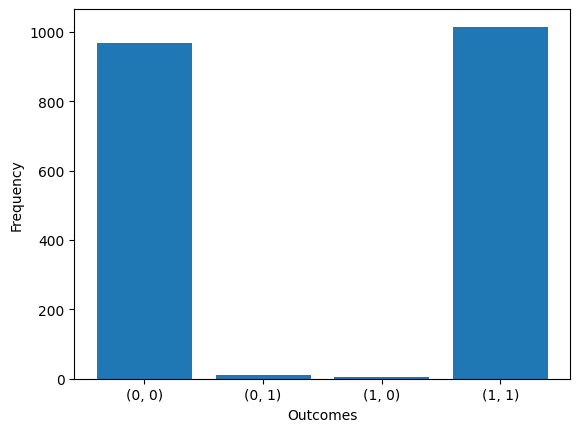

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [4]:
noisy = Machine(
    bell,
    num_qubits=4,
    registry=CallbackRegistry(),
    noise=DepolarizingNoise(error_probability=0.05),
)
noisy.shots("main", 2000).plot_histogram()

## 4. Crank the noise up

At `p = 0.2` the off-diagonal outcomes carry a few percent each — the
Bell correlations are still dominant but visibly degraded.

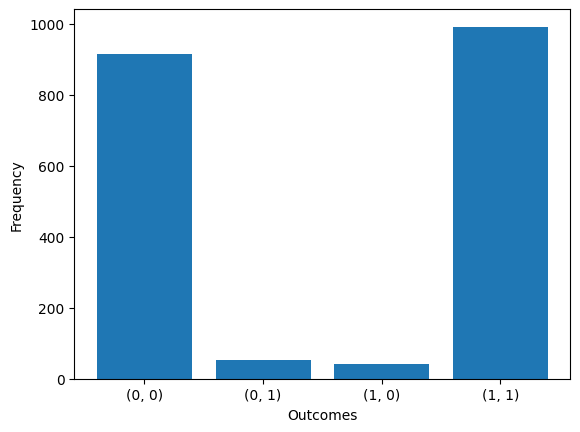

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [5]:
very_noisy = Machine(
    bell,
    num_qubits=4,
    registry=CallbackRegistry(),
    noise=DepolarizingNoise(error_probability=0.2),
)
very_noisy.shots("main", 2000).plot_histogram()

## 5. Notes

- `NoiseChannel` is an ABC; `DepolarizingNoise` is the only implementation
  ported so far, with semantics matching the legacy
  `qstack.noise.DepolarizingNoise`.
- The channel is applied per **gate** (composed onto every unitary as
  Kraus operators). Measurement-readout noise is not modeled — that is
  the same scope as the legacy emulator.
- The same `noise=…` keyword works for any module produced by the
  surface lowerer **or** by a compiler pass: try plugging the rep3
  encoder from [`rep3_demo`](rep3_demo.ipynb) on top of a noisy
  channel and watching the majority vote recover the logical bit.